# ⚽ Women's World Cup Analysis (2019 vs 2023)

This notebook analyzes offensive patterns and match dynamics using StatsBomb data from the FIFA Women's World Cup 2019 and 2023.

> 📌 This analysis supports the Medium article: [add link here]

## 📥 Data Loading

Importing datasets and combining both tournaments into a single dataframe.

In [5]:
import pandas as pd

df_2019 = pd.read_json("dataset_2019.json")
df_2023 = pd.read_json("dataset_2023.json")

df_2019["year"] = 2019
df_2023["year"] = 2023

df = pd.concat([df_2019, df_2023])

## ✅ Data Validation

Checking if the number of matches matches each tournament format.

In [6]:
df["year"].value_counts()

,count
year,
2023,64
2019,52


## ⚙️ Feature Engineering

Creating key variables used in the analysis.

In [7]:
df["total_goals"] = df["home_score"] + df["away_score"]
df["goal_diff"] = abs(df["home_score"] - df["away_score"])
df["high_scoring"] = df["total_goals"] >= 4
df["is_draw"] = df["home_score"] == df["away_score"]
df["close_game"] = df["goal_diff"] <= 1

## 📊 Average Goals per Match

In [8]:
df.groupby("year")["total_goals"].mean()

,total_goals
year,
2019,2.807692
2023,2.562500


## 🔥 High-Scoring Matches (4+ goals)

In [9]:
df.groupby("year")["high_scoring"].mean()

,high_scoring
year,
2019,0.192308
2023,0.296875


## ⚖️ Match Competitiveness

In [10]:
df.groupby("year")["goal_diff"].mean()
df.groupby("year")["close_game"].mean()

,close_game
year,
2019,0.557692
2023,0.578125


## 📈 Goal Difference Distribution

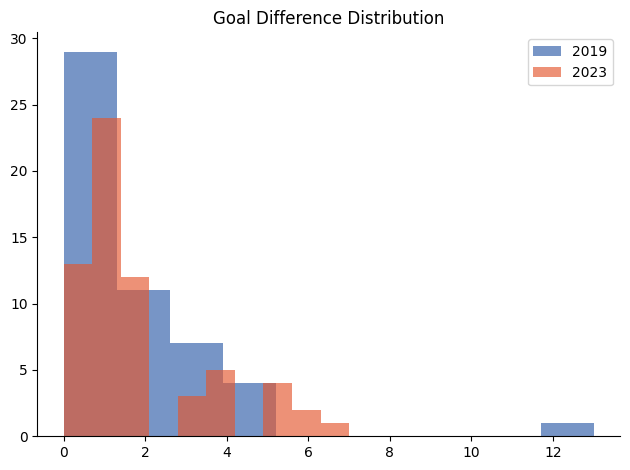

In [11]:
import matplotlib.pyplot as plt

df_2019 = df[df["year"] == 2019]
df_2023 = df[df["year"] == 2023]

plt.figure()

plt.hist(df_2019["goal_diff"], alpha=0.65, label="2019", color="#2F5DA8")
plt.hist(df_2023["goal_diff"], alpha=0.65, label="2023", color="#E4572E")

plt.title("Goal Difference Distribution")
plt.xlabel("")
plt.ylabel("")
plt.legend()

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 🤝 Draws Analysis

In [12]:
df.groupby("year")["is_draw"].mean()

,is_draw
year,
2019,0.076923
2023,0.203125


## 🧩 Conclusion

The analysis shows that:

- Average goals decreased  
- High-scoring matches increased  
- Match competitiveness remained stable  
- Draws increased significantly  

Overall, the results suggest that the tournament is becoming more unpredictable, rather than simply more or less offensive.